# 01 - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis (EDA) on the breast cancer dataset.

Goals:
- Understand the structure of the dataset (samples, features, labels).
- Inspect the class balance for the diagnosis labels.
- Explore feature distributions and correlations.
- Perform a basic PCA analysis for dimensionality reduction intuition.


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [6]:
CSV_PATH = "../data/raw/data.csv"

df = pd.read_csv(CSV_PATH)
print("Raw DataFrame shape:", df.shape)

df.head()


Raw DataFrame shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
print("=== DataFrame Info ===")
print(df.info())

print("\n=== Descriptive Statistics (Numeric Columns) ===")
display(df.describe())

print("\nColumns:")
print(df.columns.tolist())


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


=== Diagnosis Counts ===
diagnosis
B    357
M    212
Name: count, dtype: int64

=== Diagnosis Percentage (%) ===
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


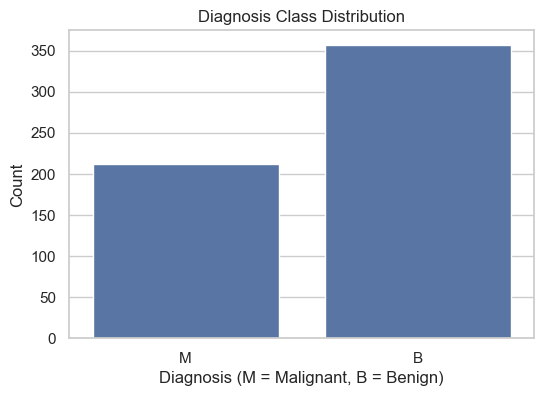

In [8]:
if "diagnosis" not in df.columns:
    raise ValueError("Column 'diagnosis' not found in the DataFrame.")

class_counts = df["diagnosis"].value_counts()
class_percent = df["diagnosis"].value_counts(normalize=True) * 100

print("=== Diagnosis Counts ===")
print(class_counts)

print("\n=== Diagnosis Percentage (%) ===")
print(class_percent.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis (M = Malignant, B = Benign)")
plt.ylabel("Count")
plt.show()


=== Missing Values per Column ===
Unnamed: 32                569
id                           0
diagnosis                    0
texture_mean                 0
radius_mean                  0
area_mean                    0
smoothness_mean              0
compactness_mean             0
perimeter_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
concavity_mean               0
smoothness_se                0
compactness_se               0
concave points_se            0
concavity_se                 0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
symmetry_se                  0
perimeter_worst              0
area_worst                   0
compactness_worst            0
smoothness_worst             0
concavity_worst              0
concave points_worst         0
symme

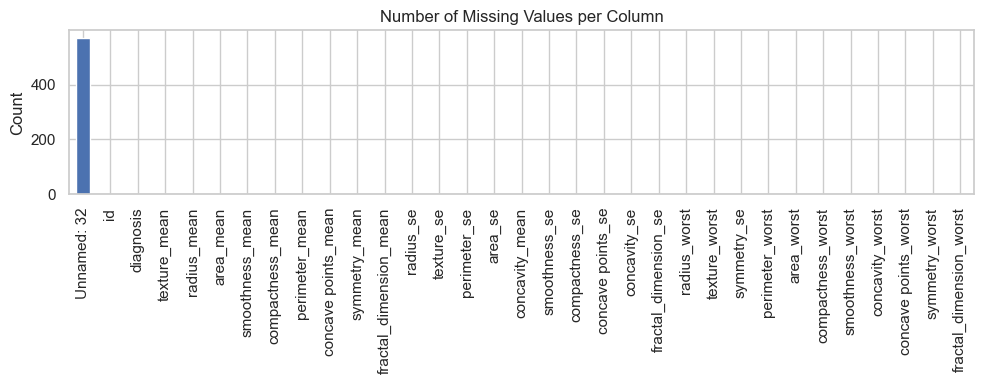

In [9]:
missing_per_column = df.isnull().sum().sort_values(ascending=False)

print("=== Missing Values per Column ===")
print(missing_per_column)

plt.figure(figsize=(10, 4))
missing_per_column.plot(kind="bar")
plt.title("Number of Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [10]:
feature_df = df.copy()

# Drop label column
if "diagnosis" in feature_df.columns:
    feature_df = feature_df.drop(columns=["diagnosis"])

# Drop ID and any Unnamed columns
cols_to_drop = [c for c in feature_df.columns if c.lower().startswith("unnamed") or c == "id"]
if cols_to_drop:
    print("Dropping:", cols_to_drop)
    feature_df = feature_df.drop(columns=cols_to_drop)

# Keep only numeric columns
feature_df = feature_df.select_dtypes(include=["number"])

print("Cleaned feature_df shape:", feature_df.shape)
feature_df.head()


Dropping: ['id', 'Unnamed: 32']
Cleaned feature_df shape: (569, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Selected features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']


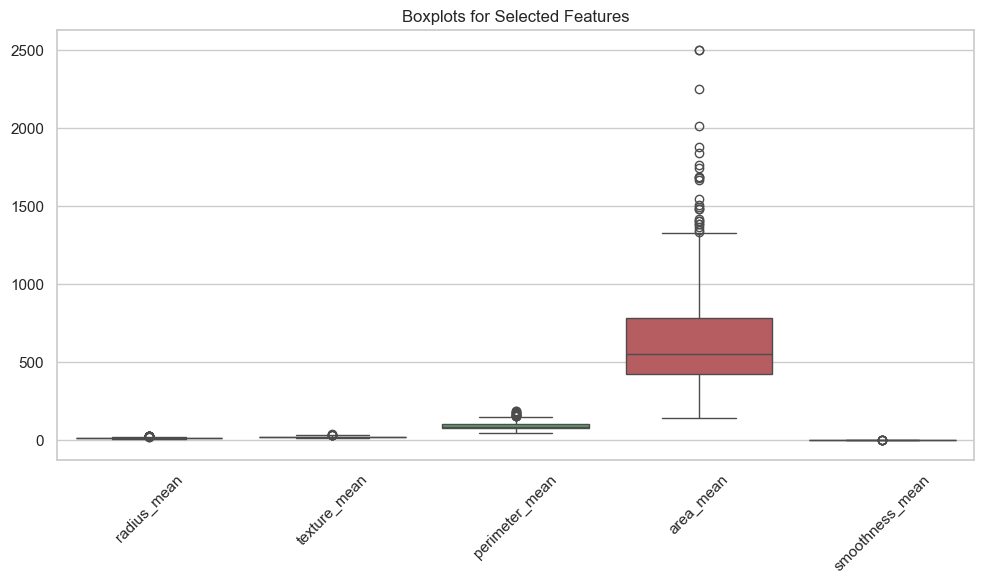

In [11]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
]

selected_features = [f for f in selected_features if f in feature_df.columns]

print("Selected features:", selected_features)

plt.figure(figsize=(10, 6))
sns.boxplot(data=feature_df[selected_features])
plt.title("Boxplots for Selected Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


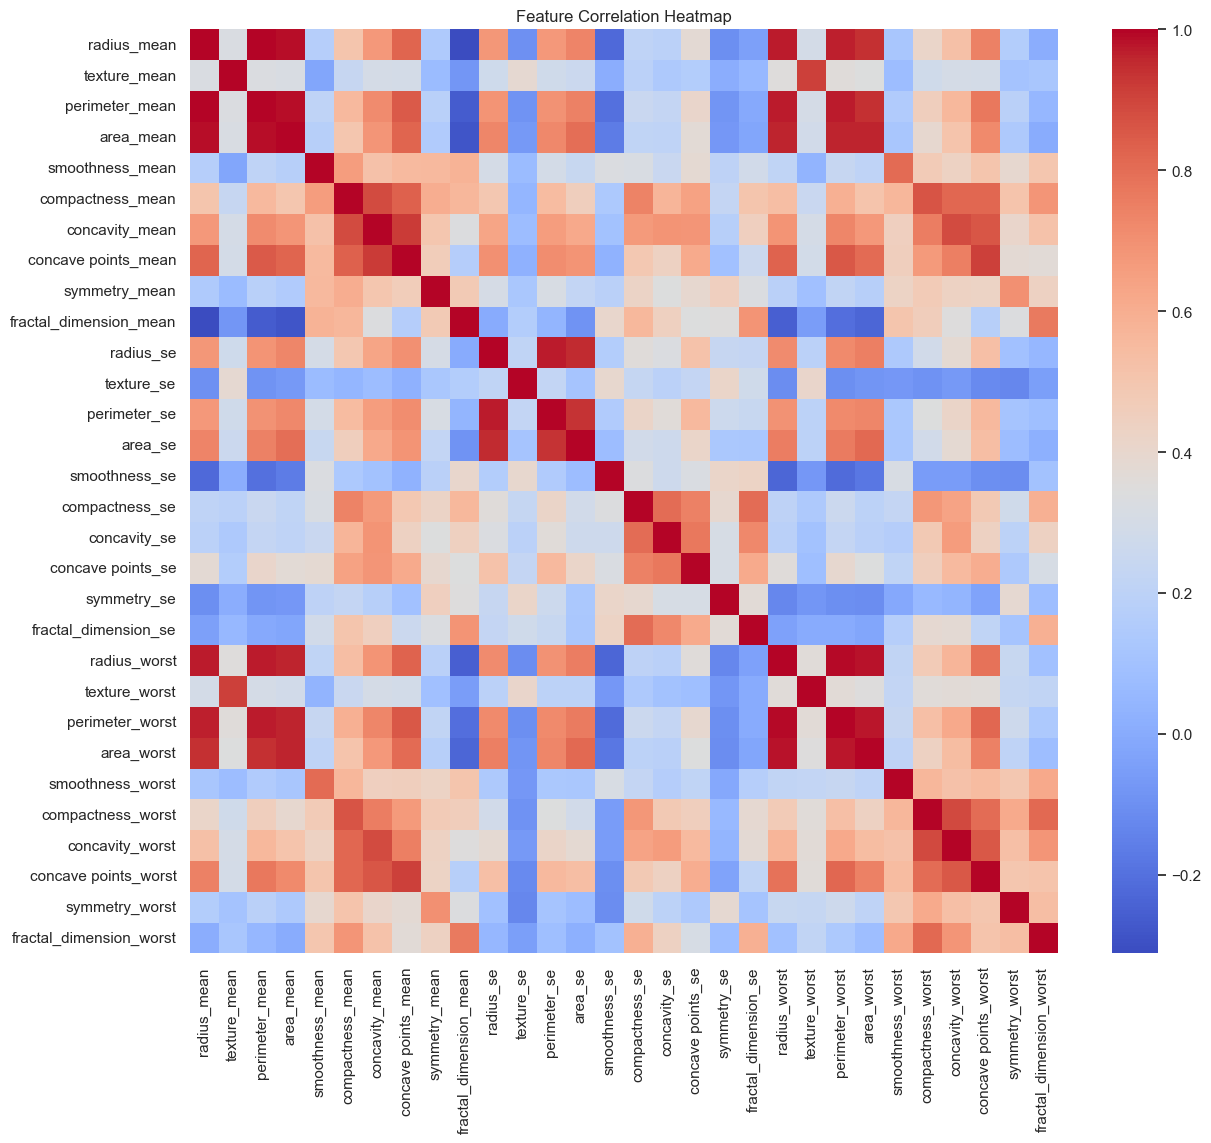

In [12]:
corr_matrix = feature_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", square=False, cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


<Figure size 1200x600 with 0 Axes>

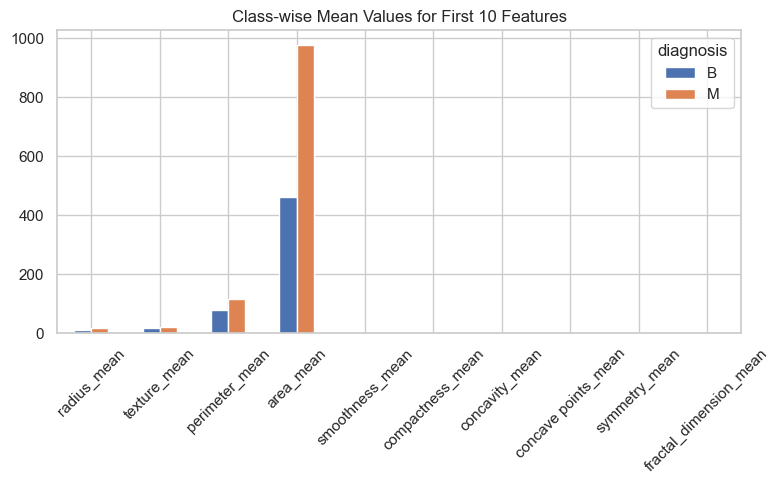

In [13]:
eda_df = feature_df.copy()
eda_df["diagnosis"] = df["diagnosis"]

group_means = eda_df.groupby("diagnosis").mean()
display(group_means)

N = 10
plt.figure(figsize=(12, 6))
group_means.iloc[:, :N].T.plot(kind="bar")
plt.title(f"Class-wise Mean Values for First {N} Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Summary and Observations

- The dataset contains **569 samples** and **30 usable numeric features** after removing the
  non-informative `id` and fully empty `Unnamed: 32` column.
  
- The diagnosis distribution is imbalanced but acceptable:
  - **Malignant (M): 212 samples**
  - **Benign (B): 357 samples**
  Benign tumors are more common, which reflects real clinical data.

- No meaningful missing-value issues were detected. Only the `Unnamed: 32` column
  contained 569 missing values and was removed entirely.

- Several features — especially **area_mean**, **perimeter_mean**, and **radius_mean** —
  show strong skewness and contain multiple outliers. This suggests that scaling and
  normalization will be important during preprocessing, particularly for distance-based
  models such as SVM.

- The correlation heatmap reveals clear clusters of highly correlated features  
  (e.g., radius–perimeter–area groups). These relationships indicate redundancy
  within the dataset and motivate the use of dimensionality-reduction or feature-selection
  techniques during modeling.

- Class-wise mean plots show that malignant tumors tend to have **larger values** in
  many geometric features (radius, perimeter, area), which aligns with biological expectations.

- Overall, the EDA confirms that:
  - the dataset is clean and ready for preprocessing,
  - scaling and normalization will be crucial,
  - correlated features may require dimensionality reduction (e.g., PCA),
  - the features contain meaningful separability between benign and malignant classes.
